In [1]:
import sys
sys.path.append('../src')

In [2]:
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import numpy as np

In [ ]:
from context_manager import TriangleIntegrandContext
from integrand_builder import IntegrandBuilder

from context_manager import TriangleIntegrandEvaluator
from wrapped_eval import WrappedEvaluator

ctx = TriangleIntegrandContext()

ib_centered = IntegrandBuilder()
ib_centered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_centered.center_counterterm_region_at_origin = True
ib_uncentered = IntegrandBuilder()
ib_uncentered.check_singularities_per_sample = False # not necessary for this example, improves performance
ib_uncentered.center_counterterm_region_at_origin = False

centered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_centered.combined_result(), ib_centered.get_args(), "centered_theta"), ctx
)
uncentered = TriangleIntegrandEvaluator(
    WrappedEvaluator(ib_uncentered.combined_result(), ib_uncentered.get_args(), "uncentered_theta"), ctx
)

Compiling evaluator: "combined_result"
Done!
Compiling evaluator: "combined_result"
Done!


# plot the integrand and threshold subtraction

In [4]:
from context_manager import norm

ctx.set_external_momenta(1, 3, 8)
qs, _ = ctx.get_ordered_qs_and_masses()

threshold_masses = [norm((qs[i]-qs[j])/2)**0.5 for (i,j) in [(0,1), (1,2), (0,2)]]
print(threshold_masses)

[np.float64(0.8660254037844386), np.float64(0.5), np.float64(1.414213562373095)]


<Figure size 2000x1000 with 0 Axes>

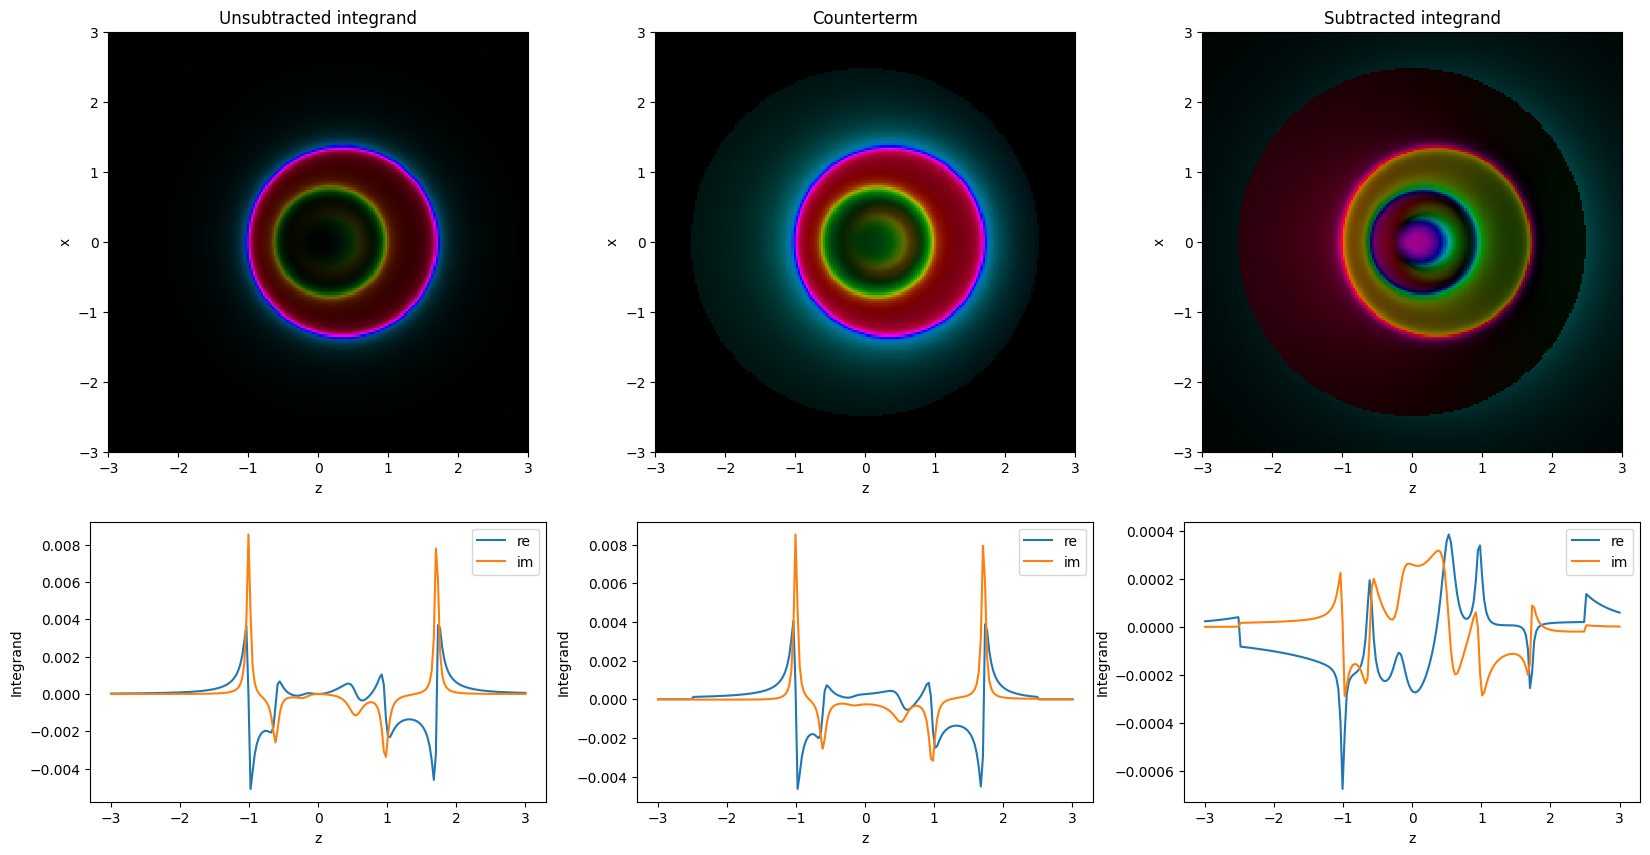

<Figure size 2000x1000 with 0 Axes>

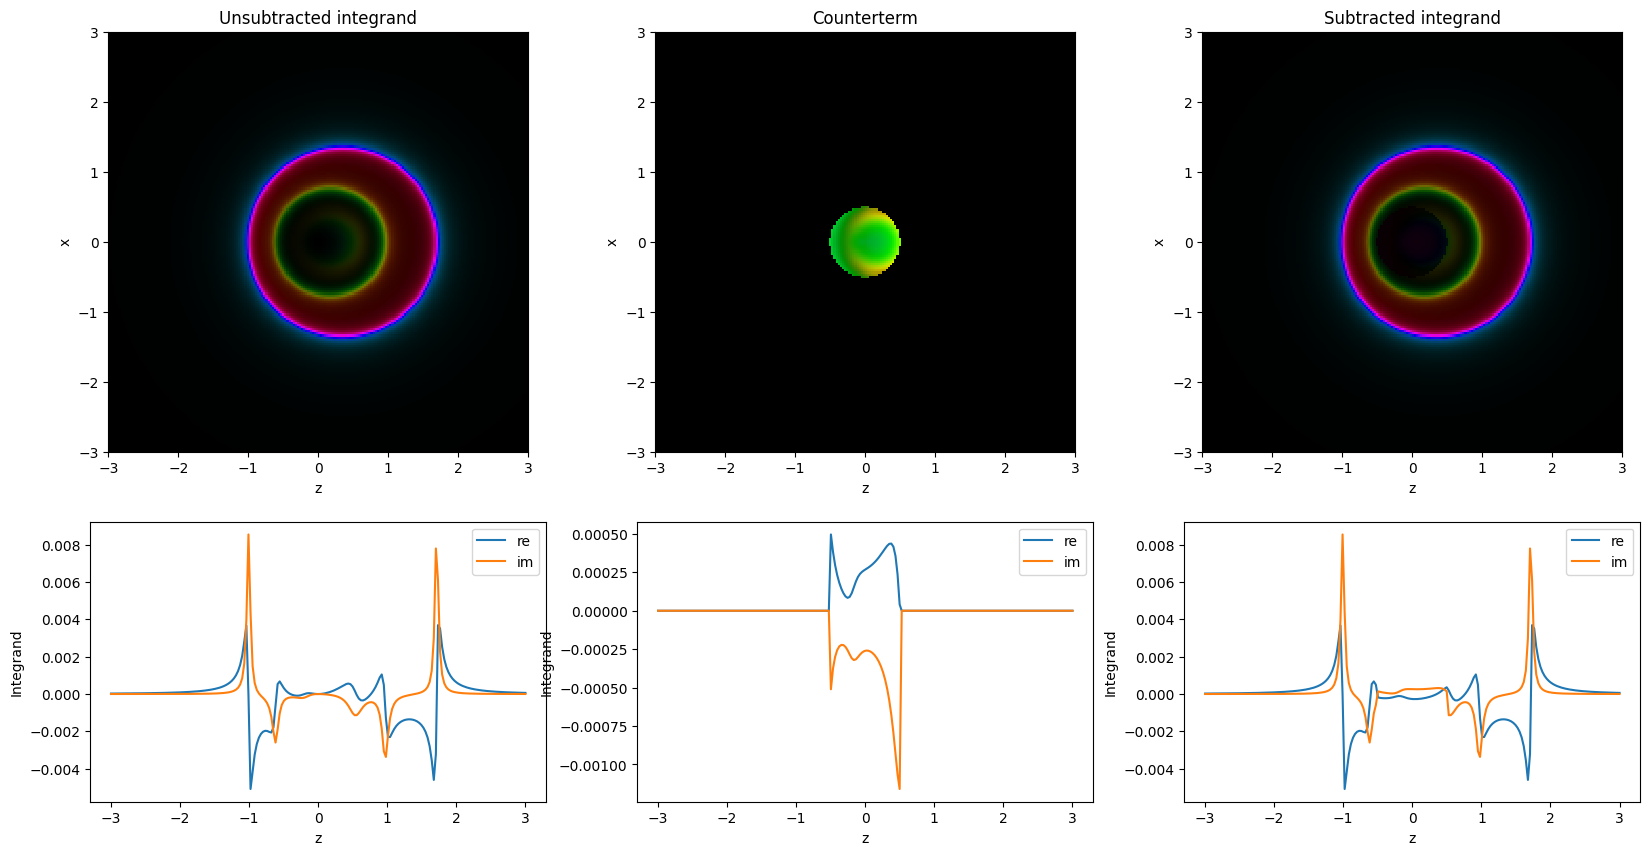

In [5]:
mass = 0.4-0.1j
ctx.masses = [mass, mass, mass]

ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
centered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/centered_subtraction.png", dpi=300)
plt.show()

ctx.subtraction_width = 0.5
ctx.mask_width = 0.5
uncentered.plot_threshold_subtraction((-3,3),(-3,3), 2,0)
plt.savefig(f"../images/small_width/centered_subtraction.png", dpi=300)
plt.show()

In [6]:
from symbolica import RandomNumberGenerator
rng = RandomNumberGenerator(0,0)

In [7]:
from context_manager import spherical
from integrator import ComplexIntegrator


def integrate_over_masses(masses, triangle, epochs = 100, steps = 500):
    results = []
    for m in tqdm(masses):
        ctx.masses = [m, m, m]
        
        ci = ComplexIntegrator(3)
        results.append(ci.integrate(triangle.eval, spherical, epochs, steps, rng))
        
        
    return results

def reference_over_masses(masses):
    ref = []
    for m in masses:
        ctx.masses = [m, m, m]
        ref.append(ctx.get_reference())
    return np.array(ref)

In [8]:
mass = 0.4
sample_masses = mass - 0.1j*0.0001**np.linspace(0,1,21)
ref_masses = mass - 0.1j*0.0001**np.linspace(0,1,50)

ctx.combined_integrand()

ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
centered_res = integrate_over_masses(sample_masses, centered)


ctx.subtraction_width = 2.5
ctx.mask_width = 2.5
uncentered_res = integrate_over_masses(sample_masses, uncentered)

ctx.only_unsubtracted()
unsubtracted_res = integrate_over_masses(sample_masses, centered)

ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

########################################################################
#                                                                      #
#                        You are using OneLOop                         #
#                                                                      #
# for the evaluation of 1-loop scalar 1-, 2-, 3- and 4-point functions #
#                                                                      #
# author: Andreas van Hameren <hamerenREMOVETHIS@ifj.edu.pl>           #
#   date: 2024-11-23                                                   #
#                                                                      #
# Please cite                                                          #
#    A. van Hameren,                                                   #
#      Comput.Phys.Commun. 182 (2011) 2427-2438, arXiv:1007.4716       #
#    A. van Hameren, C.G. Papadopoulos and R. Pittau,                  #
#      JHEP 0909:106,2009, arXiv:0903.4665         

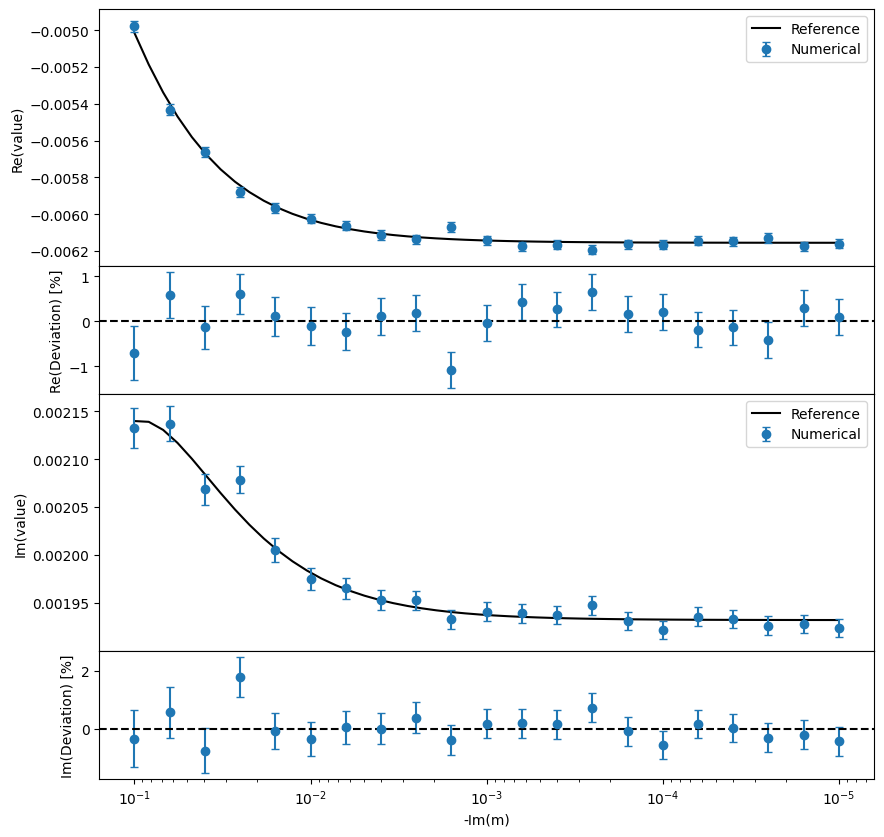

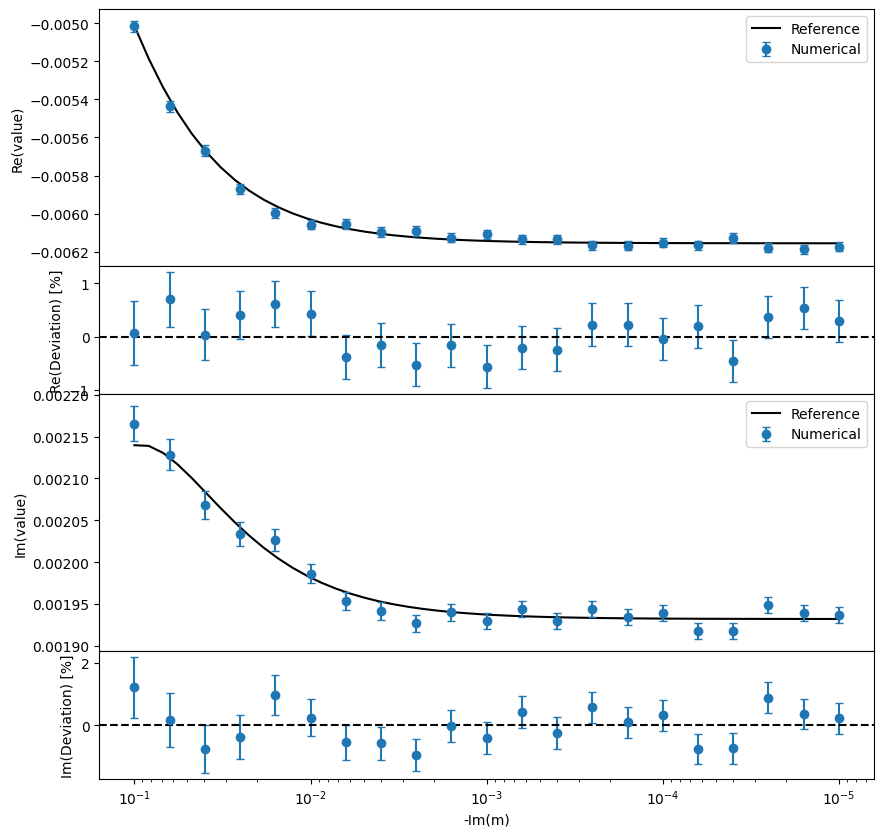

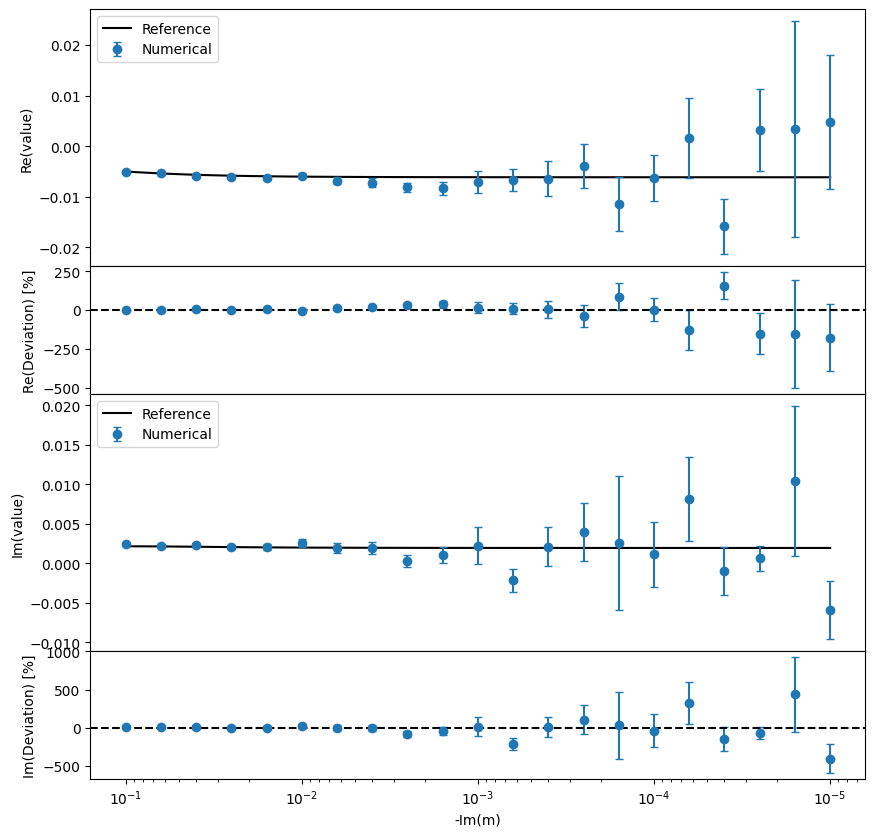

In [9]:
from plot_util import plot_complex_integration_with_ref


ref = reference_over_masses(ref_masses)
ref_same_x = reference_over_masses(sample_masses)

fig = plot_complex_integration_with_ref(
    centered_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.savefig(f"../images/small_width/integration_centered.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    uncentered_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.savefig(f"../images/small_width/integration_uncentered.png", dpi=300)
plt.show()


fig = plot_complex_integration_with_ref(
    unsubtracted_res, ref_same_x, -sample_masses.imag, ref, -ref_masses.imag
)
fig.get_axes()[-1].set_xscale('log')
fig.get_axes()[-1].xaxis.set_inverted(True)
fig.get_axes()[-1].set_xlabel('-Im(m)')
plt.savefig(f"../images/small_width/integration_unsubtracted.png", dpi=300)
plt.show()

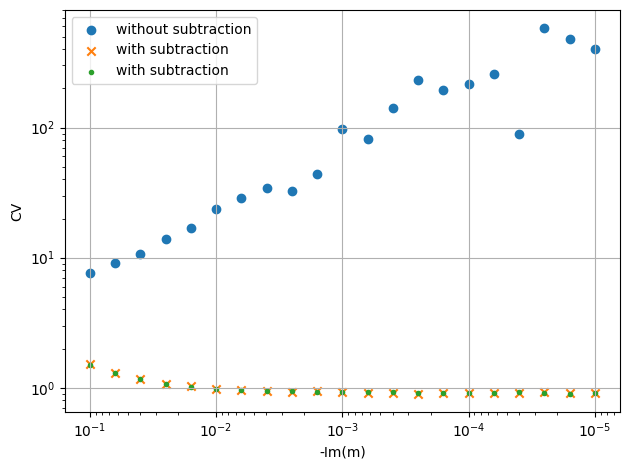

In [10]:
plt.scatter(-sample_masses.imag, [r.cv() for r in unsubtracted_res], label = 'without subtraction', marker='o')
plt.scatter(-sample_masses.imag, [r.cv() for r in centered_res],  label = 'with subtraction', marker='x')
plt.scatter(-sample_masses.imag, [r.cv() for r in uncentered_res],  label = 'with subtraction', marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('-Im(m)')
plt.ylabel('CV')
plt.gca().xaxis.set_inverted(True)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"../images/small_width/cv.png", dpi=300)
plt.show()